In [3]:
%reload_ext autoreload
%autoreload 2
%cd ../

/home/hazzu/Code/thesis


In [ ]:
# import os

# SELFIES_DIR = "datasets/selfies"
# selfies_name = os.listdir(SELFIES_DIR)

# CARD_DIR = "datasets/cards"
# cards_name = os.listdir(CARD_DIR)

# cnt = 0
# for id, name in [name.split("_") for name in selfies_name]:
#     is_exist = any([id in card_name for card_name in cards_name])
#     if is_exist:
#         cnt += 1
#     else:
#         print(id, name)

# print(cnt)

24T1020459 TranDangNhatThanh
24T1020404 PhamVanAnhQuoc
23T1020591 LuongVietMinhTuan
24T1020463 NguyenPhuocThien
24T1020519 LeAnhTu
24T1020536 TranXuanTuan
23T1020154 DoTrongHao
24T1020100 NguyenDacHieuDung
24T1020428 LeTanTai
23T1020190 LeNguyenCuuHuan
24T1020526 PhanCongTuan
24T1020262 NguyenManhLoc
23T1020175 TranDinhQuangHieu
24T1020594 DangThanhPhuoc
23T1020525 VoVanThuan
24T1020474 TranHuuThong
24T1020383 NguyenKimTheQuan
23T1020265 PhamNguyenNhatKhanh
23T1020314 TranPhiLong
24T1020126 TranNgocHan
74


In [ ]:
# import os

# SELFIES_DIR = "datasets/selfies"
# SELFIES_DUAL_DIR = "datasets/selfies_dual"

# selfies_name = os.listdir(SELFIES_DIR)
# selfies_dual_name = os.listdir(SELFIES_DUAL_DIR)

# for name in selfies_name:
#     if name not in selfies_dual_name:
#         print(name)

21T1020267_NguyenVuHoangChuong
21T1020031_TranThiThanhHue
21T1020340_NgoVanHai
23T1020262_DangBachBaoKhanh


In [1]:
threshold_1 = 0.331
threshold_2 = 0.314

In [5]:
import pandas as pd

genuine_test_1_pd = pd.read_csv(
    "results/compare-sfaces/SFace + KD (SFace-OpenCV) (0.3) (ver2)/genuine_pairs_test.csv"
)
genuine_test_2_pd = pd.read_csv(
    "results/compare-sfaces/SFace + KD (SFace-OpenCV) Fine-tuning/genuine_pairs_test.csv"
)
imposter_test_1_pd = pd.read_csv(
    "results/compare-sfaces/SFace + KD (SFace-OpenCV) (0.3) (ver2)/imposter_pairs_test.csv"
)
imposter_test_2_pd = pd.read_csv(
    "results/compare-sfaces/SFace + KD (SFace-OpenCV) Fine-tuning/imposter_pairs_test.csv"
)

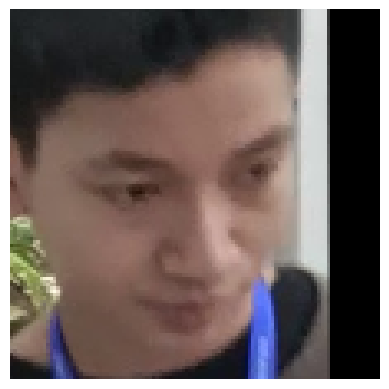

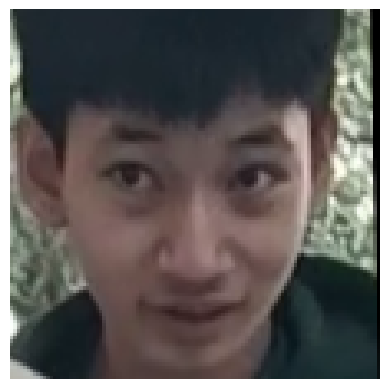

datasets/ver2/selfies_2/24T1020493_NguyenVanToan/vlcsnap-00083.png datasets/ver2/selfies_2/24T1020493_NguyenVanToan/vlcsnap-2024122500109.png 0.29612008 0.32348612


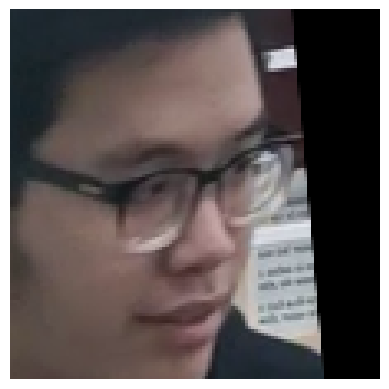

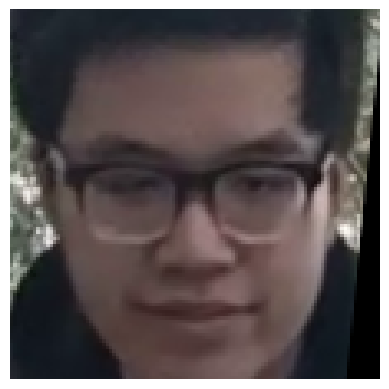

datasets/ver2/selfies_2/24T1020482_PhamHuuThuan/vlcsnap-2024122500108.png datasets/ver2/selfies_2/24T1020482_PhamHuuThuan/vlcsnap-2024122500106.png 0.3066599 0.398025


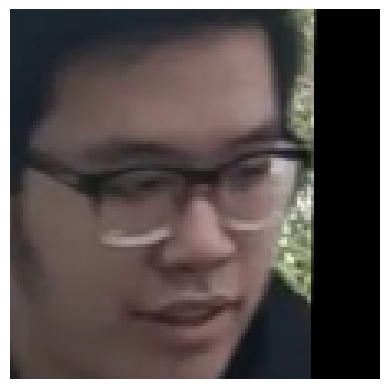

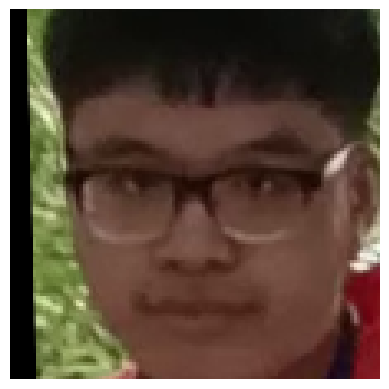

datasets/ver2/selfies_2/24T1020482_PhamHuuThuan/vlcsnap-2024122500107.png datasets/ver2/selfies_2/24T1020482_PhamHuuThuan/vlcsnap-00078.png 0.27288595 0.37314266


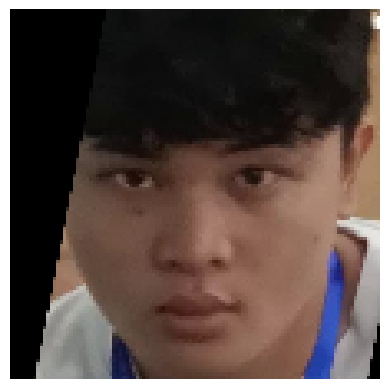

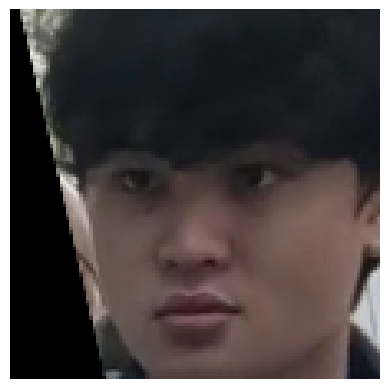

datasets/ver2/selfies_2/24T1020520_NguyenMinhTu/vlcsnap-00010.png datasets/ver2/selfies_2/24T1020520_NguyenMinhTu/vlcsnap-2024122500140.png 0.29451403 0.36520416


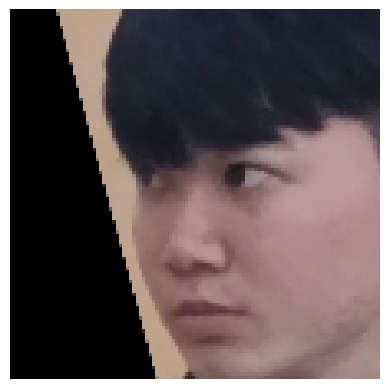

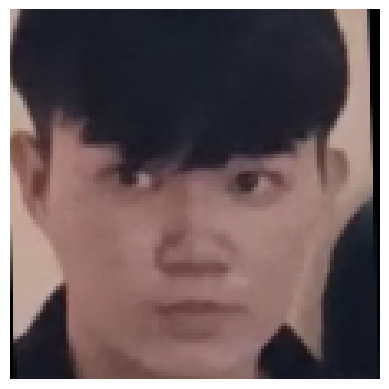

datasets/ver2/selfies_2/23T1020540_TrinhVanTien/vlcsnap-2024122500069.png datasets/ver2/selfies_2/23T1020540_TrinhVanTien/vlcsnap-2024122500067.png 0.32540712 0.3487877


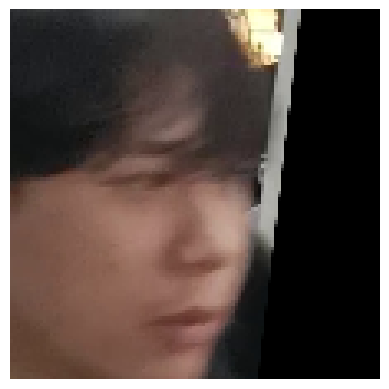

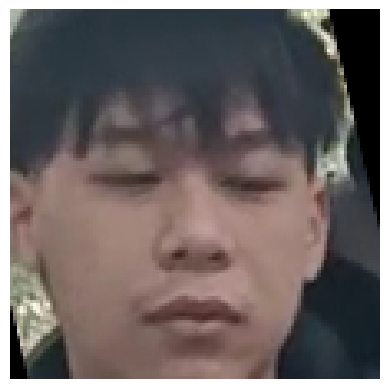

datasets/ver2/selfies_2/24T1020467_HaQuangThinh/vlcsnap-00068.png datasets/ver2/selfies_2/24T1020467_HaQuangThinh/vlcsnap-2024122500097.png 0.2805012 0.3540178


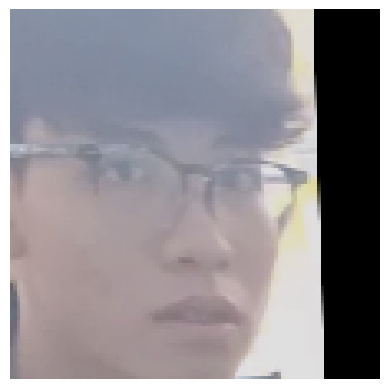

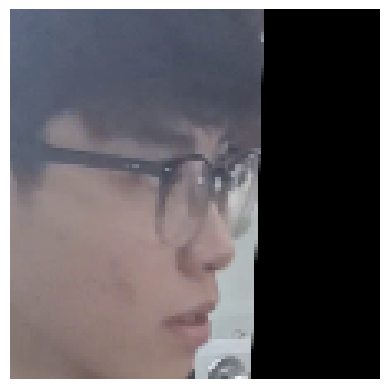

datasets/ver2/selfies_2/24T1020369_VoLeAnPhuc/vlcsnap-2024122500013.png datasets/ver2/selfies_2/24T1020369_VoLeAnPhuc/vlcsnap-2024122500053.png 0.29781276 0.3205414


In [25]:
import matplotlib.pyplot as plt
import cv2, os
from tqdm import tqdm
from lib.face_detector.retinaface import RetinaFaceDetector
from lib.face_recognizer.arcface import ArcFaceRecognizer
from insightface.utils import face_align

retinaface = RetinaFaceDetector()
arcface = ArcFaceRecognizer()

image1_paths = genuine_test_1_pd["image1_path"].tolist()
image2_paths = genuine_test_1_pd["image2_path"].tolist()
sim1 = genuine_test_1_pd["similarity"].tolist()
sim2 = genuine_test_2_pd["similarity"].tolist()

for image1_path, image2_path, s1, s2 in zip(image1_paths, image2_paths, sim1, sim2):
    if s1 < threshold_1 and s2 >= threshold_2:

        image1 = cv2.imread(image1_path)
        faces = retinaface.detect(image1)
        if len(faces) == 0:
            print(f"Face not found in {image1_path}")
            continue
        if len(faces) > 1:
            print(f"{len(faces)} faces found in {image1_path}")
            continue

        face = faces[0]
        arcface_face = arcface._convert_input_face(face)
        aligned_face = face_align.norm_crop(
            image1,
            landmark=arcface_face.kps,
            image_size=arcface._recognizer.input_size[0],
        )
        plt.imshow(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

        image2 = cv2.imread(image2_path)
        faces = retinaface.detect(image2)
        if len(faces) == 0:
            print(f"Face not found in {image2_path}")
            continue
        if len(faces) > 1:
            print(f"{len(faces)} faces found in {image2_path}")
            continue

        face = faces[0]
        arcface_face = arcface._convert_input_face(face)
        aligned_face = face_align.norm_crop(
            image2,
            landmark=arcface_face.kps,
            image_size=arcface._recognizer.input_size[0],
        )
        plt.imshow(cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
        print(f"{image1_path} {image2_path} {s1} {s2}")

In [20]:
import matplotlib.pyplot as plt

image1_paths = imposter_test_1_pd["image1_path"].tolist()
image2_paths = imposter_test_1_pd["image2_path"].tolist()
sim1 = imposter_test_1_pd["similarity"].tolist()
sim2 = imposter_test_2_pd["similarity"].tolist()

for image1_path, image2_path, s1, s2 in zip(image1_paths, image2_paths, sim1, sim2):
    if s1 >= threshold_1 and s2 < threshold_2:
        plt.imshow(plt.imread(image1_path))
        plt.axis("off")
        plt.show()
        plt.imshow(plt.imread(image2_path))
        plt.axis("off")
        plt.show()
        print(f"{image1_path} {image2_path} {s1} {s2}")